# 2.1. Training: Gene signatures
# 2.1. 模型训练：基因特征

### 📘 Overview
### 📘 概述

This notebook performs quality control on raw count data to filter out low-quality cells, and then uses DESeq2 to compute differential gene expression signatures (compound vs. DMSO) for each compound.
这个notebook对原始计数数据进行质量控制，过滤掉低质量细胞，然后使用DESeq2计算每个化合物的差异基因表达特征（化合物 vs. DMSO对照）。

**Inputs**  
**输入数据**  
Raw gene expression count matrix
原始基因表达计数矩阵

**Output**  
**输出**  
An AnnData file with DESeq2 differential expression results (log₂ fold changes, adjusted p-values)
包含DESeq2差异表达结果的AnnData文件（log₂折叠变化、调整后的p值）

### ⚠️ 重要提示：专有数据访问

**请注意**：原始训练数据文件是专有的，受知识产权限制保护。只有在签署数据共享协议并符合机构政策后才会共享。

**如果您遇到 S3 访问错误**：
1. **申请数据访问权限**：请联系 DILImap@cellarity.com 或访问项目 GitHub Issues 页面
2. **使用本地数据**：如果您已有本地数据文件，代码会自动尝试从以下路径加载：
   - `training_data_counts.h5ad`
   - `../data/training_data_counts.h5ad`
   - `./data/training_data_counts.h5ad`
3. **检查访问权限**：如果您已有访问权限，请检查 S3 凭证配置和网络连接

**Note**  
Please note that raw training data files are proprietary due to IP restrictions and will only be shared upon request, subject to data-sharing agreements and institutional policies.

In [13]:
import numpy as np
import pandas as pd
import anndata as ad

import seaborn as sns
import matplotlib.pyplot as plt

import dilimap as dmap

In [14]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
dmap.logging.print_version()

Running dilimap 0.2.dev20+gc285bd842 (python 3.10.19) on 2025-11-20 01:20.


## Pull raw data
## 拉取原始数据

从S3读取原始训练数据（专有数据，需要访问权限）。

In [17]:
# 尝试从 S3 读取专有训练数据
# 注意：这些数据是专有的，需要数据共享协议才能访问
# 如果遇到访问错误，请参考下面的错误处理说明

try:
    adata = dmap.s3.read('training_data_counts.h5ad', package_name='proprietary/data')
    print("✓ 成功从 S3 加载数据")
except Exception as e:
    error_msg = str(e)
    print("=" * 80)
    print("❌ 无法从 S3 访问专有训练数据")
    print("=" * 80)
    print("\n错误信息：")
    print(f"  {error_msg}\n")
    print("原因：")
    print("  这些训练数据文件是专有的，受知识产权限制保护。")
    print("  只有在签署数据共享协议并符合机构政策后才会共享。\n")
    print("解决方案：")
    print("  1. 如果您已有数据访问权限，请检查：")
    print("     - S3 凭证是否正确配置")
    print("     - 网络连接是否正常")
    print("     - 是否已签署数据共享协议\n")
    print("  2. 如果您需要申请数据访问权限，请联系：")
    print("     - DILImap@cellarity.com")
    print("     - 或访问项目 GitHub Issues 页面\n")
    print("  3. 如果您已有本地数据文件，可以使用以下代码加载：")
    print("     adata = ad.read_h5ad('path/to/your/local/training_data_counts.h5ad')\n")
    print("=" * 80)
    
    # 尝试从本地文件加载（如果存在）
    import os
    local_paths = [
        'training_data_counts.h5ad',
        '../data/training_data_counts.h5ad',
        './data/training_data_counts.h5ad',
    ]
    
    loaded = False
    for path in local_paths:
        if os.path.exists(path):
            try:
                print(f"\n尝试从本地路径加载: {path}")
                adata = ad.read_h5ad(path)
                print(f"✓ 成功从本地文件加载数据: {path}")
                loaded = True
                break
            except Exception as local_e:
                print(f"  ✗ 无法从 {path} 加载: {local_e}")
    
    if not loaded:
        raise RuntimeError(
            "无法加载训练数据。请申请数据访问权限或提供本地数据文件。\n"
            "联系邮箱: DILImap@cellarity.com"
        )

Package: s3://dilimap/proprietary/data. Top hash: ede9d7c164
❌ 无法从 S3 访问专有训练数据

错误信息：
  An error occurred (NoSuchVersion) when calling the GetObject operation: The specified version does not exist.

原因：
  这些训练数据文件是专有的，受知识产权限制保护。
  只有在签署数据共享协议并符合机构政策后才会共享。

解决方案：
  1. 如果您已有数据访问权限，请检查：
     - S3 凭证是否正确配置
     - 网络连接是否正常
     - 是否已签署数据共享协议

  2. 如果您需要申请数据访问权限，请联系：
     - DILImap@cellarity.com
     - 或访问项目 GitHub Issues 页面

  3. 如果您已有本地数据文件，可以使用以下代码加载：
     adata = ad.read_h5ad('path/to/your/local/training_data_counts.h5ad')



RuntimeError: 无法加载训练数据。请申请数据访问权限或提供本地数据文件。
联系邮箱: DILImap@cellarity.com

In [18]:
from dilimap.utils import platemap

In [ ]:
## Example plate design
## 示例板设计

展示实验板的设计布局，包括化合物位置和剂量水平。

adata.obs['WELL_ROW'] = adata.obs['WELL_ID'].str[0]
adata.obs['WELL_COL'] = adata.obs['WELL_ID'].str[1:]

data = adata[adata.obs['PLATE_NAME'] == 'RR1_S2']

CMPD_COLOR = (
    data.obs['COMPOUND']
    .map(
        {
            'DMSO': 'seashell',
            'DMSO_replaced': 'seashell',
            'Chlorpromazine': 'lightsalmon',
        }
    )
    .fillna('lightblue')
)
CMPD_COLOR_OPACITY = '; opacity: ' + data.obs['DOSE_LEVEL'].astype(str).map(
    {'Control': '1', 'Low': '.4', 'Middle': '.6', 'Mid-High': '.8', 'High': '1'}
)


def highlight_cells(x):
    return (
        'background-color: '
        + x.map(dict(zip(data.obs['CMPD_DOSE'], CMPD_COLOR))).fillna('white')
        + x.map(dict(zip(data.obs['CMPD_DOSE'], CMPD_COLOR_OPACITY)))
    )


df_cmpd_map = platemap(data, value_key='CMPD_DOSE', batch='PLATE_NAME')

col_borders = dict(subset=['4', '8'], **{'border-right': '1.5pt solid black'})
row_borders = dict(
    subset=(df_cmpd_map.index.str.endswith(('A', 'D', 'G')), df_cmpd_map.columns),
    **{'border-top': '1.5pt solid black'},
)

display(
    df_cmpd_map.style.apply(highlight_cells)
    .set_properties(**col_borders)
    .set_properties(**row_borders)
)

NameError: name 'adata' is not defined

## QC (total counts, mtRNA, rRNA)
## 质量控制（总计数、线粒体RNA、核糖体RNA）

对数据进行质量控制，检查：
- 总RNA计数
- 线粒体RNA百分比（mtRNA）
- 核糖体RNA百分比（rRNA）

In [ ]:
adata.obs['LDH_QC'].value_counts()

LDH_QC
              3978
tech error     181
cell death      16
Name: count, dtype: int64

In [ ]:
adata.obs['ldh_qc_pass'] = adata.obs['LDH_QC'] == ''
# 创建LDH（乳酸脱氢酶）质量控制标志：如果LDH_QC为空字符串，则通过QC

In [ ]:
## QC of total counts and mtRNA
## 总计数和线粒体RNA的质量控制

dmap.pp.qc_metrics(adata)
# 计算质量控制指标：log总RNA、线粒体RNA百分比、核糖体RNA百分比

thresh_counts = (
    np.median(adata.obs['log_totalRNA']) - 2.5 * adata.obs['log_totalRNA'].std()
)
# 计算总RNA阈值：中位数减去2.5倍标准差（用于过滤低质量细胞）
adata.obs['rna_qc_pass'] = (adata.obs['log_totalRNA'] > thresh_counts) & (
    adata.obs['pct_mtRNA'] < 9
)
# 创建RNA质量控制标志：总RNA > 阈值 且 线粒体RNA百分比 < 9%

print(f'Total RNA cutoff = {int(10**thresh_counts)}')
# 打印总RNA阈值（转换为原始计数）

Added the following to `adata.obs`: ['log_totalRNA', 'pct_mtRNA', 'pct_rRNA']
Total RNA cutoff = 732678


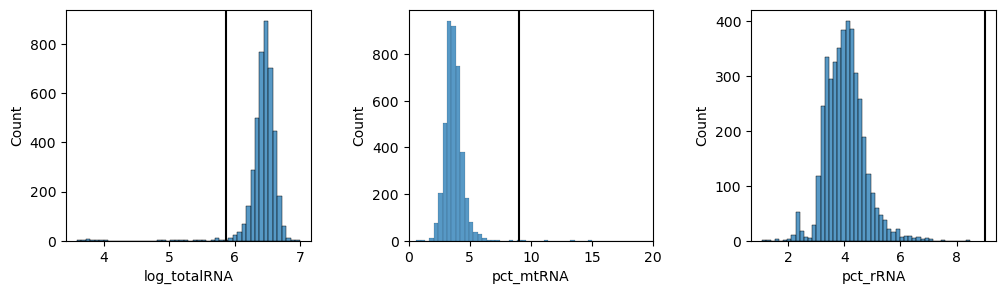

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(12, 3), gridspec_kw={'wspace': 0.4})

sns.histplot(adata.obs['log_totalRNA'], bins=50, ax=axs[0])
sns.histplot(adata.obs['pct_mtRNA'], bins=200, ax=axs[1])
sns.histplot(adata.obs['pct_rRNA'], bins=50, ax=axs[2])

axs[1].set_xlim(0, 20)

axs[0].axvline(thresh_counts, c='k')
axs[1].axvline(9, c='k')
axs[2].axvline(9, c='k')

plt.show()

In [ ]:
## Example plate with QC metrics
## 带有QC指标的示例板

可视化单个实验板的QC指标，显示哪些细胞通过了质量控制。

data = adata[adata.obs['PLATE_NAME'] == 'RR1_S2']


def color_boolean(val):
    return f'color: {"lightred" if val else ""}; font-weight: {"bold" if val else ""}'


for val in ['log_totalRNA', 'pct_mtRNA']:
    print(f'\033[1m{val}')

    df = platemap(data, val, batch='PLATE_NAME')
    df_bool = np.invert(platemap(data, 'rna_qc_pass', batch='PLATE_NAME').astype(bool))

    if val != 'notes_flags':
        mu, std = np.median(data.obs[val]), np.std(data.obs[val])

        display(
            df.style.format(precision=2)
            .background_gradient(vmin=mu - 3 * std, vmax=mu + 3 * std, cmap='RdBu_r')
            .apply(lambda c: df_bool[c.name].apply(color_boolean))
            .map(lambda x: 'background-color: white' if pd.isnull(x) else '')
            .set_properties(**col_borders)
            .set_properties(**row_borders)
        )

    else:
        display(
            df.style.format(precision=2)
            .apply(lambda c: df_bool[c.name].apply(color_boolean))
            .map(lambda x: 'background-color: salmon' if x != '' else '')
            .set_properties(**col_borders)
            .set_properties(**row_borders)
        )

log_totalRNA


/var/folders/lz/prv79nmj5msg8h6nzqn0w7cw0000gn/T/ipykernel_22385/3827332189.py:22: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda x: 'background-color: white' if pd.isnull(x) else '')


,1,2,3,4,5,6,7,8,9,10,11,12
RR1_S2_A,6.31,6.63,6.56,6.56,6.45,6.53,6.68,6.59,6.64,6.61,6.52,6.51
RR1_S2_B,6.47,6.50,6.66,6.43,6.57,6.40,6.74,6.62,6.62,6.60,6.58,6.43
RR1_S2_C,6.56,6.40,6.13,6.28,6.18,6.61,6.62,6.14,6.58,6.66,6.63,6.63
RR1_S2_D,6.27,6.50,6.43,6.56,6.42,6.39,6.41,6.34,6.13,6.43,6.43,6.23
RR1_S2_E,6.69,6.62,6.67,6.57,6.65,3.82,3.73,6.61,6.56,6.63,6.74,3.87
RR1_S2_F,6.60,6.54,6.35,6.30,6.63,6.57,6.71,6.30,6.72,6.58,6.70,6.57
RR1_S2_G,6.50,6.68,6.59,6.60,6.45,6.57,6.29,6.45,6.60,6.53,6.52,6.48


pct_mtRNA


/var/folders/lz/prv79nmj5msg8h6nzqn0w7cw0000gn/T/ipykernel_22385/3827332189.py:22: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda x: 'background-color: white' if pd.isnull(x) else '')


,1,2,3,4,5,6,7,8,9,10,11,12
RR1_S2_A,3.30,3.68,3.90,3.51,3.30,3.08,3.16,3.65,3.47,3.00,2.90,2.49
RR1_S2_B,3.09,3.34,3.55,3.83,3.19,3.26,2.41,2.97,2.89,2.84,2.62,2.13
RR1_S2_C,2.62,2.17,2.33,2.41,2.51,2.58,2.12,2.43,2.42,2.17,2.45,2.40
RR1_S2_D,3.31,3.46,3.65,3.71,3.66,3.30,3.45,3.30,2.72,2.91,2.54,2.61
RR1_S2_E,3.82,3.99,3.87,4.24,4.14,3.45,3.54,3.75,3.24,3.15,2.88,3.42
RR1_S2_F,3.35,2.96,3.27,3.42,3.62,3.13,3.19,2.86,2.56,2.49,2.39,2.30
RR1_S2_G,3.19,2.71,3.17,3.08,3.38,3.26,3.11,2.67,2.30,2.38,2.15,1.89


## QC (cross-replicate correlation)
## 质量控制（跨重复相关性）

检查同一化合物-剂量组合的不同重复之间的相关性，过滤掉相关性低的重复。

In [ ]:
dmap.pp.qc_cross_rep_correlation(adata, group_key='CMPD_DOSE', plate_key='PLATE_NAME')
# 计算跨重复相关性：对每个化合物-剂量组合，计算不同重复之间的相关性
# group_key: 用于分组的列（化合物-剂量组合）
# plate_key: 实验板列名

Added the following to `adata.obs`: ['cross_rep_correlation', 'rep_corr_qc_pass']


In [ ]:
## Example plate with cross-replicate correlations
## 带有跨重复相关性的示例板

可视化单个实验板的跨重复相关性，显示哪些重复通过了相关性检查。

data = adata[adata.obs['PLATE_NAME'] == 'RR1_S2']

val = 'cross_rep_correlation'

df = platemap(data, val, batch='PLATE_NAME')
df_bool = np.invert(
    platemap(data, 'rep_corr_qc_pass', batch='PLATE_NAME').fillna(False).astype(bool)
)
mu, std = np.nanmean(data.obs[val]), np.nanstd(data.obs[val])

col_borders = dict(subset=['4', '8'], **{'border-right': '1.5pt solid black'})
row_borders = dict(
    subset=(df.index.str.endswith(('A', 'D', 'G')), df.columns),
    **{'border-top': '1.5pt solid black'},
)

print(val, f'CI=[{mu - 2 * std:0.3f},{1}]')
display(
    df.style.format(precision=3)
    .background_gradient(vmin=mu - 5 * std, vmax=1, cmap='Reds_r')
    .apply(lambda c: df_bool[c.name].apply(color_boolean))
    .map(lambda x: 'background-color: white' if pd.isnull(x) else '')
    .set_properties(**col_borders)
    .set_properties(**row_borders)
)

cross_rep_correlation CI=[0.990,1]


/var/folders/lz/prv79nmj5msg8h6nzqn0w7cw0000gn/T/ipykernel_22385/2606076238.py:18: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda x: 'background-color: white' if pd.isnull(x) else '')


,1,2,3,4,5,6,7,8,9,10,11,12
RR1_S2_A,0.997,1.000,0.999,0.994,0.999,0.999,0.999,0.998,0.997,0.999,0.998,0.994
RR1_S2_B,0.999,1.000,0.999,0.994,0.999,0.999,0.998,0.999,0.998,0.999,0.999,0.996
RR1_S2_C,0.999,0.995,0.997,0.994,0.998,0.998,0.998,0.997,0.998,0.998,0.999,0.996
RR1_S2_D,0.998,0.997,0.999,0.995,0.999,0.997,0.998,0.996,0.999,0.998,0.995,0.998
RR1_S2_E,0.999,0.997,0.997,0.996,0.997,0.984,0.979,0.995,0.999,0.998,0.995,0.978
RR1_S2_F,0.999,0.997,0.999,0.996,0.999,0.997,0.998,0.996,0.999,0.997,0.995,0.998
RR1_S2_G,0.999,0.998,0.999,0.998,0.999,0.999,0.999,0.997,0.999,0.999,0.999,0.999


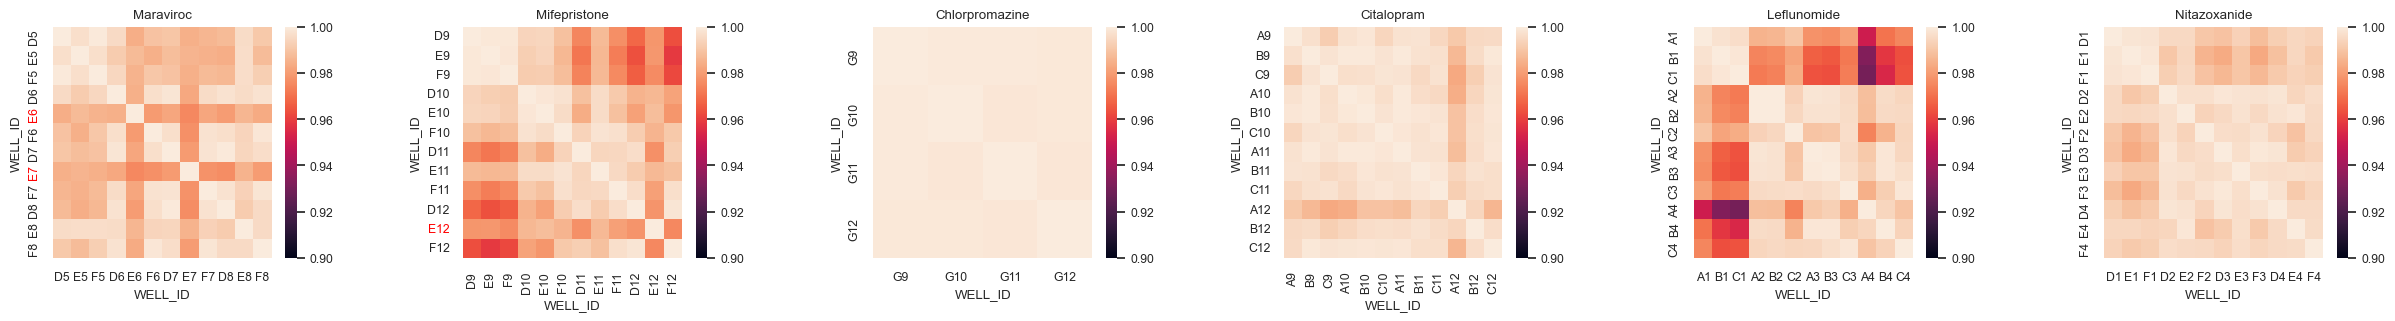

In [ ]:
from natsort import index_natsorted

sns.set(font_scale=0.8)

df_cmpd_flags = data.obs[~data.obs['rep_corr_qc_pass']]['COMPOUND'].value_counts()
df_cmpd_flags = df_cmpd_flags[~df_cmpd_flags.index.str.contains('DMSO')]
cmpd_flags = df_cmpd_flags.index[:8]

fig, axs = plt.subplots(
    1, len(cmpd_flags), figsize=(5 * len(cmpd_flags), 3), gridspec_kw={'wspace': 0.5}
)
for i, cmpd_name in enumerate(cmpd_flags):
    df_sub = data[data.obs['COMPOUND'] == cmpd_name].to_df()
    df_sub.index = data[data.obs['COMPOUND'] == cmpd_name].obs['WELL_ID']

    df_sub_corr = df_sub.T.corr()
    idx_sort = index_natsorted(df_sub_corr.index.str[1:] + df_sub_corr.index.str[0])
    df_sub_corr = df_sub_corr.iloc[idx_sort, idx_sort]

    g = sns.heatmap(df_sub_corr, vmax=1, vmin=0.9, yticklabels=True, ax=axs[i])

    flagged = (
        data[(data.obs['COMPOUND'] == cmpd_name) & ~data.obs['rep_corr_qc_pass']]
        .obs['WELL_ID']
        .values
    )
    for label in g.get_yticklabels():
        if label.get_text() in flagged:
            label.set_color('red')

    axs[i].set_title(cmpd_name)

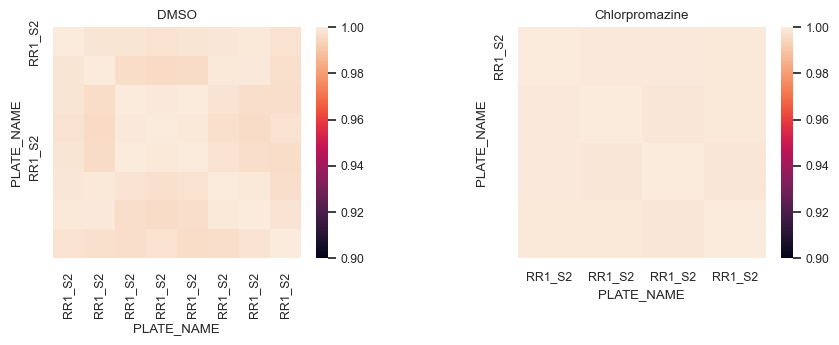

In [ ]:
cmpd_flags = ['DMSO', 'Chlorpromazine']

fig, axs = plt.subplots(
    1, len(cmpd_flags), figsize=(5 * len(cmpd_flags), 3), gridspec_kw={'wspace': 0.5}
)
for i, cmpd_name in enumerate(cmpd_flags):
    df_sub = data[data.obs['COMPOUND'] == cmpd_name].to_df()
    df_sub.index = data[data.obs['COMPOUND'] == cmpd_name].obs['PLATE_NAME'].astype(str)

    df_sub_corr = df_sub.T.corr()
    idx_sort = index_natsorted(df_sub_corr.index.str[1:] + df_sub_corr.index.str[0])
    df_sub_corr = df_sub_corr.iloc[idx_sort, idx_sort]

    g = sns.heatmap(df_sub_corr, vmax=1, vmin=0.9, yticklabels=4, ax=axs[i])

    flagged = (
        data[(data.obs['COMPOUND'] == cmpd_name) & ~data.obs['rep_corr_qc_pass']]
        .obs['WELL_ID']
        .values
    )
    for label in g.get_yticklabels():
        if label.get_text() in flagged:
            label.set_color('red')

    axs[i].set_title(cmpd_name)

## QC (hepatocyte fidelity sanity check)
## 质量控制（肝细胞保真度检查）

检查细胞是否确实是肝细胞，通过检查肝细胞标志基因的表达来验证。

In [ ]:
# Log-normalize total counts (similar to sc.pp.normalize_total and sc.pp.log1p)
# 对数标准化总计数（类似于scanpy的normalize_total和log1p）

X = adata.X if isinstance(adata.X, np.ndarray) else adata.X.toarray()
# 获取计数矩阵（如果是稀疏矩阵则转换为密集矩阵）
cell_sums = X.sum(axis=1, keepdims=True)
# 计算每个细胞的总计数
X_norm = (X / cell_sums) * np.median(cell_sums)
# 标准化：每个细胞除以总计数，然后乘以中位数总计数
X_norm = np.log10(X_norm + 1)
# 对数转换（log10(x+1)）

adata_norm = ad.AnnData(X=X_norm, obs=adata.obs, var=adata.var)
# 创建归一化后的AnnData对象

/opt/anaconda3/envs/py310/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [ ]:
# Celltype markers curated from https://panglaodb.se/markers.html and https://pmc.ncbi.nlm.nih.gov/articles/PMC6687507
# 细胞类型标志基因，来自panglaodb和文献

marker_celltypes = {
    # Hepatocytes, cluster 14 in liver atlas
    # 肝细胞，肝脏图谱中的cluster 14
    'Hepatocytes': [
        'ALB',
        'CYP3A4',
        'APOA1',
        'APOA2',
        'APOC3',
        'TF',
        'APOH',
        'ALDOB',
        'TTR',
        'GSTA2',
    ],
    # Kupffer, from panglaodb
    # 库普弗细胞（肝脏巨噬细胞），来自panglaodb
    'Kupffer': ['C1QB', 'C1QA', 'CD163', 'MAFB', 'CSF1R', 'CLEC4F', 'FCNA', 'ADGRE1'],
    # Liver Sinusoidal Endothelial Cells (LSEC), cluster 9 in liver atlas
    # 肝窦内皮细胞，肝脏图谱中的cluster 9
    'LSEC': ['EGFL7', 'FLT1', 'CLEC4M', 'CLEC4G', 'FCN3', 'STAB1', 'DNASE1L3'],
    # Hepatic Stellate Cells (HSC), from panglaodb
    # 肝星状细胞，来自panglaodb
    'HSC': ['IGFBP6', 'COL1A2', 'SPARC', 'TPM2', 'COL3A1', 'MYL9', 'DCN'],
    # Cholangiocyte, cluster 4+7 in liver atlas
    # 胆管细胞，肝脏图谱中的cluster 4+7
    'Cholangiocyte': ['AGR2', 'ELF3', 'CLDN4', 'KRT7', 'AQP1'],  # "KRT19",
    # Dedifferentiation, low in mature, high in dedifferentiated
    # 去分化标志，在成熟细胞中低表达，在去分化细胞中高表达
    'Dedifferentiated': [
        'KRT19',  # Biliary/progenitor marker
        # 胆管/祖细胞标志
        'EPCAM',  # Also indicates epithelial progenitors
        # 也指示上皮祖细胞
        'LAMB1',  # ECM remodeling and stress-induced dedifferentiation
        # 细胞外基质重塑和应激诱导的去分化
        'PROM1',  # Progenitor/stemness marker
        # 祖细胞/干性标志
        'LGR5',  # Liver progenitor marker
        # 肝脏祖细胞标志
        'AFP',  # Strongly fetal/hepatoblast marker
        # 强烈的胎儿/肝母细胞标志
    ],
}

all_markers = np.hstack(list(marker_celltypes.values()))
# 合并所有标志基因
all_markers = [g for g in all_markers if g in adata_norm.var_names]
# 只保留在数据中存在的标志基因

idx = (
    adata_norm.obs['ldh_qc_pass']
    & adata_norm.obs['rna_qc_pass']
    & adata_norm.obs['rep_corr_qc_pass']
)
# 创建索引：只选择通过所有QC检查的细胞
marker_expr = adata_norm[
    idx & (adata_norm.obs['COMPOUND'] == 'DMSO'), all_markers
].to_df()

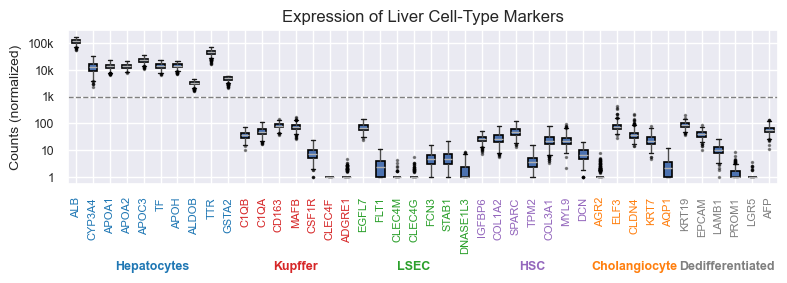

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Color palette
celltype_palette = {
    'Hepatocytes': '#1f77b4',
    'Kupffer': '#d62728',
    'LSEC': '#2ca02c',
    'HSC': '#9467bd',
    'Cholangiocyte': '#ff7f0e',
    'Dedifferentiated': '#7f7f7f',
}

# Flatten mapping: gene → celltype
marker_to_celltype = {g: ct for ct, genes in marker_celltypes.items() for g in genes}
genes = list(marker_expr.columns)
celltypes = [marker_to_celltype.get(g, 'Unknown') for g in genes]

# Plot
fig, ax = plt.subplots(figsize=(8, 3.5))
flierprops = dict(
    marker='o', markersize=1.5, linestyle='none', markerfacecolor='black', alpha=0.4
)
box = marker_expr.boxplot(
    rot=90,
    patch_artist=True,
    flierprops=flierprops,
    boxprops=dict(color='black', linewidth=1.2),
    ax=ax,
)

# Main x-axis: gene names
xticks = np.arange(1, len(genes) + 1)
ax.set_xticks(xticks)
ax.set_xticklabels(genes, rotation=90, fontsize=8)
for label in ax.get_xticklabels():
    gene = label.get_text()
    celltype = marker_to_celltype.get(gene, 'black')
    label.set_color(celltype_palette.get(celltype, 'black'))

# Y-axis: log10(counts) → raw counts
ax.set_yticks([0, 1, 2, 3, 4, 5])
ax.set_yticklabels(['1', '10', '100', '1k', '10k', '100k'])

# Horizontal guide
ax.axhline(3, ls='--', lw=1, color='gray')

# Compute midpoints for grouped cell types
unique_blocks = []
start_idx = 0
for i in range(1, len(genes)):
    if celltypes[i] != celltypes[i - 1]:
        mid = (start_idx + i - 1) / 2 + 1
        unique_blocks.append((mid, celltypes[i - 1]))
        start_idx = i
mid = (start_idx + len(genes) - 1) / 2 + 1
unique_blocks.append((mid, celltypes[-1]))

# Add cell type labels below the plot (just below x-axis)
y_pos = -0.5  # adjust as needed
for x, label_text in unique_blocks:
    ax.text(
        x,
        y_pos,
        label_text,
        ha='center',
        va='top',
        fontsize=9,
        fontweight='bold',
        color=celltype_palette.get(label_text, 'black'),
        transform=ax.get_xaxis_transform(),
    )

# Final touches
ax.set_title('Expression of Liver Cell-Type Markers', fontsize=12)
ax.set_ylabel('Counts (normalized)', fontsize=10)
plt.tight_layout()
plt.show()

## DESeq2
## DESeq2差异表达分析

使用DESeq2对每个化合物进行差异表达分析，计算相对于DMSO对照的log2折叠变化和调整后的p值。

In [ ]:
%%capture

from dask.distributed import LocalCluster, Client

cluster = LocalCluster(n_workers=8, threads_per_worker=1, memory_limit='auto')
# 创建本地Dask集群：8个工作进程，每个进程1个线程
client = Client(cluster)
# 创建Dask客户端（用于并行处理DESeq2分析）

In [ ]:
# 检查 adata 是否已定义
if 'adata' not in globals():
    raise NameError(
        "错误：'adata' 变量未定义。\n"
        "请确保已成功运行前面的数据加载 cell（Cell 5）。\n"
        "如果遇到 S3 访问错误，请：\n"
        "1. 申请数据访问权限（联系 DILImap@cellarity.com）\n"
        "2. 或提供本地数据文件\n"
        "3. 或检查数据加载 cell 的输出"
    )

# 检查 adata 是否为空
if adata is None:
    raise ValueError("错误：'adata' 为空。请检查数据加载是否成功。")

# 检查必要的列是否存在
if 'PLATE_NAME' not in adata.obs.columns:
    raise ValueError("错误：'adata.obs' 中缺少 'PLATE_NAME' 列。请检查数据格式。")

print(f"开始 DESeq2 分析...")
print(f"总细胞数: {adata.n_obs}")
print(f"总基因数: {adata.n_vars}")
print(f"Plate 数量: {len(np.unique(adata.obs['PLATE_NAME']))}")

adatas = {}
# 存储每个plate的DESeq2结果

for plate in np.unique(adata.obs['PLATE_NAME']):
    # 对每个实验板分别进行DESeq2分析
    # 从原始数据中提取当前 plate 的数据
    adata_batch = adata[adata.obs['PLATE_NAME'] == plate].copy()
    
    # 使用 adata_batch 的 QC 标志进行过滤（注意：使用 adata_batch，不是 adata_norm）
    # adata_norm 是用于可视化分析的归一化数据，不应该用于 DESeq2 分析
    # 确保 QC 标志存在且长度匹配
    if 'ldh_qc_pass' not in adata_batch.obs.columns:
        raise ValueError(f"缺少 'ldh_qc_pass' 列。请确保已运行 QC 步骤。")
    if 'rna_qc_pass' not in adata_batch.obs.columns:
        raise ValueError(f"缺少 'rna_qc_pass' 列。请确保已运行 QC 步骤。")
    if 'rep_corr_qc_pass' not in adata_batch.obs.columns:
        raise ValueError(f"缺少 'rep_corr_qc_pass' 列。请确保已运行 QC 步骤。")
    
    # 过滤通过 QC 的细胞
    qc_mask = (
        adata_batch.obs['ldh_qc_pass']
        & adata_batch.obs['rna_qc_pass']
        & adata_batch.obs['rep_corr_qc_pass']
    )
    # 只保留通过所有QC检查的细胞
    adata_batch = adata_batch[qc_mask].copy()

    # 确保观察名称唯一
    adata_batch.obs_names_make_unique()

    # 运行 DESeq2 分析
    print(f"处理 plate: {plate}, 细胞数: {adata_batch.n_obs}")
    adatas[plate] = dmap.pp.deseq2(
        adata_batch,
        pert_name_col='COMPOUND',
        # 扰动名称列（化合物名称）
        other_pert_cols=['DOSE_LEVEL'],
        # 其他扰动列（剂量水平）
        dask_client=client,
        # 使用Dask客户端进行并行计算
    )

    adatas[plate].obs['PLATE_NAME'] = plate
    # 保存plate名称

NameError: name 'adata' is not defined

In [ ]:
adata_deseq = ad.concat(adatas.values(), join='outer')
# 合并所有plate的DESeq2结果
# join='outer'：保留所有基因（即使某些plate中缺失）

ValueError: No objects to concatenate

In [ ]:
adata_deseq = adata_deseq[~np.all(np.isnan(adata_deseq.X), 1)].copy()
# 删除所有值都是NaN的行（即没有有效DESeq2结果的化合物）

## Push file to S3
## 将文件推送到S3

保存DESeq2分析结果到S3存储，供后续模型训练使用。

In [ ]:
# dmap.s3.write(adata_deseq, 'training_data_deseq2.h5ad', package_name='proprietary/data')